# ML bacteria
使用Machine Learning对bacteria(论文“Rapid identification of pathogenic bacteria using Raman spectroscopy and deep learning”)中finetune数据集进行训练并预测test数据集。(3000个样本（3000行）、30个细菌分类的拉曼数据)


## 1 原始数据进行训练预测

In [2]:
import numpy as np

# 载入finetune数据集
X_f = './data/X_finetune.npy'
y_f = './data/y_finetune.npy'
X_train = np.load(X_f)
y_train = np.load(y_f)

X_f = './data/X_test.npy'
y_f = './data/y_test.npy'
X_test = np.load(X_f)
y_test = np.load(y_f)

In [3]:
import training
from sklearn.svm import SVC
svm_clf = SVC(kernel='linear') # 使用SVM模型
best_estimator=training.train_the_model(svm_clf,X_train,y_train)

In train dataset, model accuracy is 0.9060 (+/- 0.0265) 


In [4]:
y_pred=training.test_the_model(best_estimator,X_test,y_test) # 测试

Accuracy: 0.786


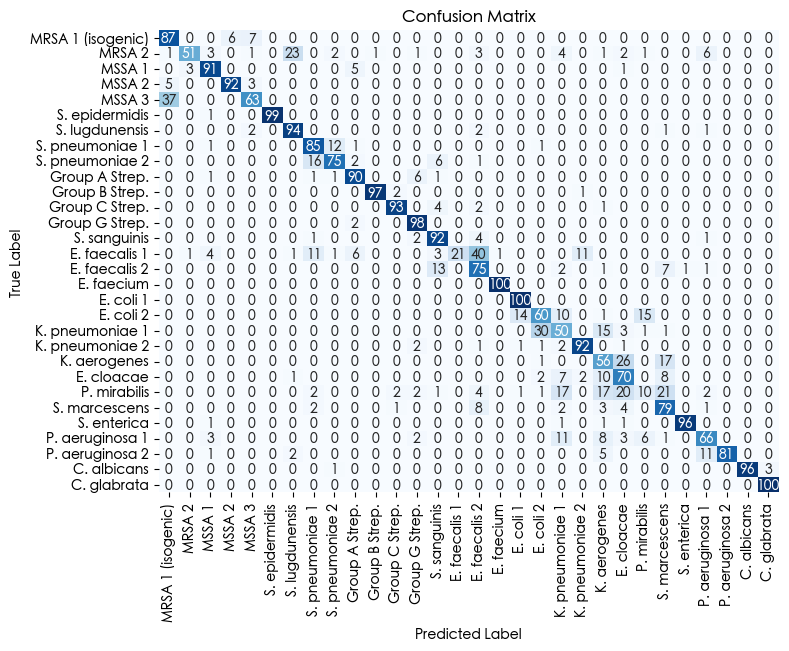

In [5]:
from utils import plot_confusion_matrix
plot_confusion_matrix(y_test, y_pred)  # 预测结果的confusion_matrix图

## 2 预处理数据进行训练预测
对train与test数据集进行光滑去噪、基线化后再训练与预测。

In [6]:
from scipy.signal import savgol_filter
from pybaselines import Baseline

def sg_smooth(ys):
    # 定义窗口大小（必须是奇数）
    window_size = 11
    
    # 定义多项式的阶数
    polyorder = 3
    
    # 使用savgol_filter函数计算窗口移动多项式平滑
    ysn = savgol_filter(ys, window_length=window_size, polyorder=polyorder)
    return ysn

def airpls_baseline(ys, x=None):
    # Baseline对象需要x轴坐标, 此时利用ys数组最后一个维度的长度(Feature的个数)生成了一个伪坐标[0, 1, 2, ..., ]
    # (由于Raman中波数基本等间隔，因此这个坐标与实际坐标线性一一映射)
    if x is None:
        x = list(range(ys.shape[-1]))
    baseline_fitter = Baseline(x_data=x) 

    ys_airpls = []
    for y in ys:
        bkg, params = baseline_fitter.airpls(y, lam=1e5) #自适应加权惩罚最小二乘法
        ys_airpls.append(y - bkg)
    return np.array(ys_airpls)

### 2.1 先平滑再基线

In [7]:
# 对X_train数据进行savgol平滑与airpls降噪
X_train_sg = sg_smooth(X_train)
X_train_airpls = airpls_baseline(X_train_sg)

# 对X_test数据进行savgol平滑与airpls降噪
X_test_sg = sg_smooth(X_test)
X_test_airpls = airpls_baseline(X_test_sg)

In [11]:
cv_results = training.train_the_model(SVC(kernel='linear'),X_train_airpls,y_train)

In train dataset, model accuracy is 0.9223 (+/- 0.0261) 


In [13]:
y_pred=training.test_the_model(cv_results,X_test_airpls,y_test)

Accuracy: 0.789


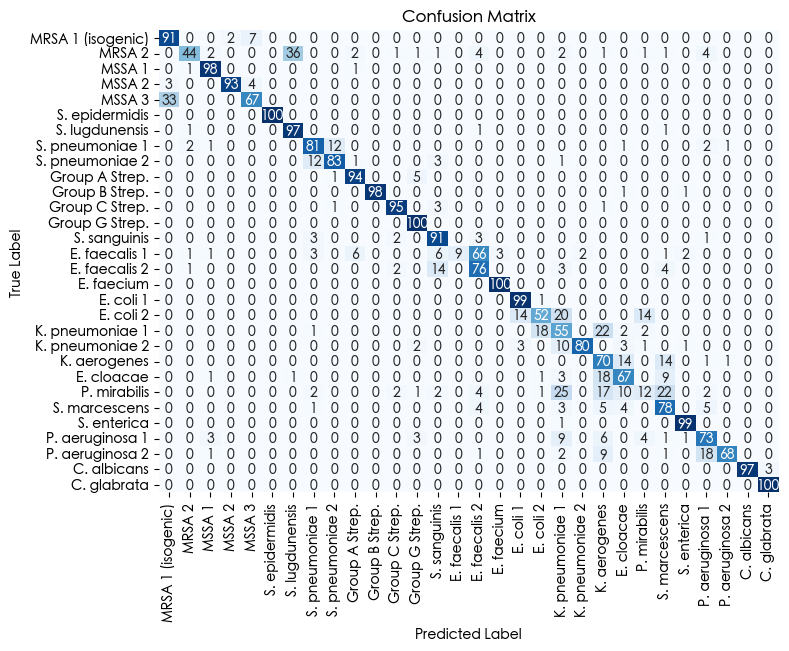

In [14]:
plot_confusion_matrix(y_test, y_pred)

### 2.2 先基线再平滑

In train dataset, model accuracy is 0.9247 (+/- 0.0332) 
Accuracy: 0.809


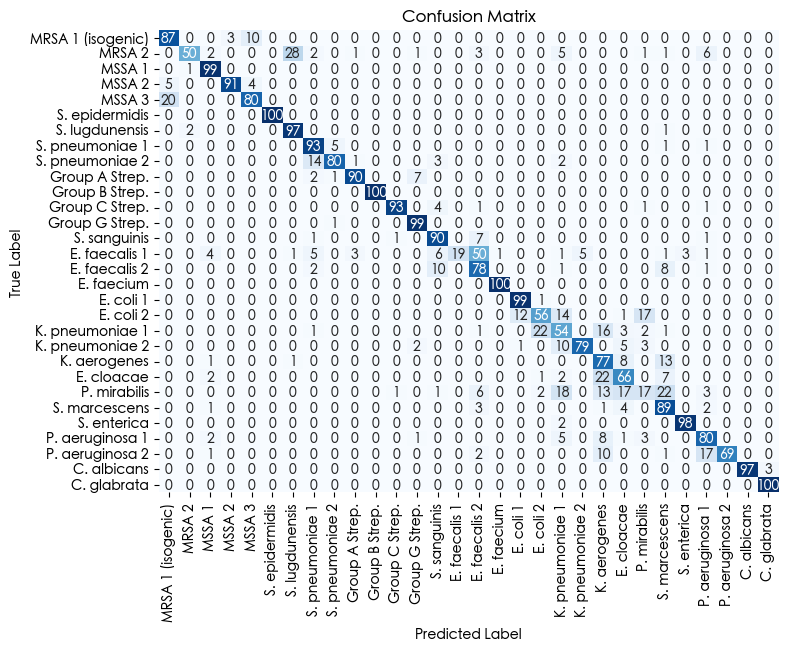

In [15]:
X_train_ag = sg_smooth(airpls_baseline(X_train))
X_test_ag = sg_smooth(airpls_baseline(X_test))

cv_results = training.train_the_model(SVC(kernel='linear'),X_train_ag,y_train)
y_pred=training.test_the_model(cv_results,X_test_ag,y_test)
plot_confusion_matrix(y_test, y_pred)

**从结果上来看，先基线化再平滑化，模型效果会更好。实际上一般ML时，无论前面处理时是否做过平滑，在最后再来一次平滑可能效果更好。**

## 3 作业
实际上面有许多代码块重复多次，应提取至函数中，这样如果发生修改时只需要修改一处而不需多处修改（多处修改易遗漏且麻烦）。
1) 请把上面重复代码提取到函数方法中，并能使代码可通。(可以先复制本代码文件，并在复制后的文件中修改)
2) 使用其它ML的模型，看能否提升test数据集上的准确率

In train dataset, model accuracy is 0.7863 (+/- 0.0587) 
Accuracy: 0.672


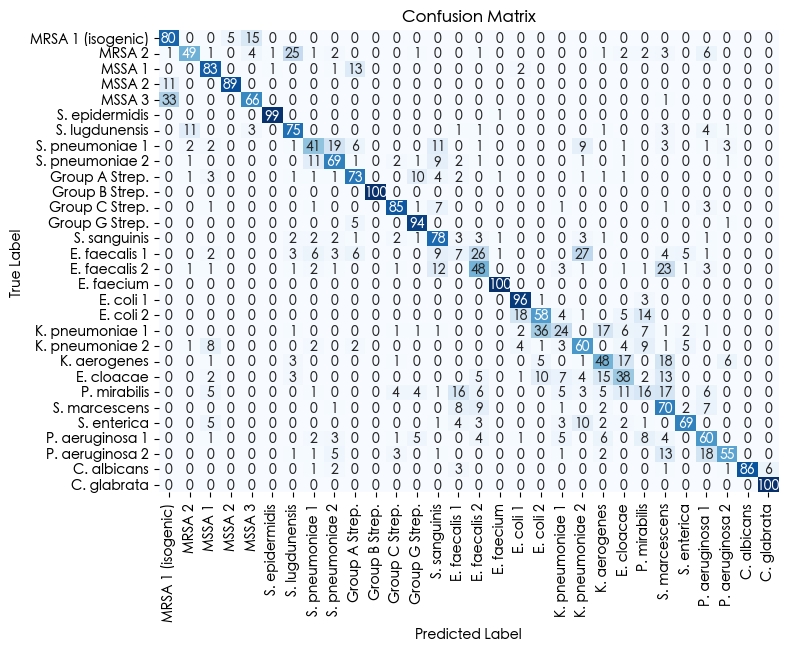

In [28]:
from sklearn.ensemble import RandomForestClassifier
cv_results = training.train_the_model(RandomForestClassifier(criterion='gini',n_estimators=100,random_state=42),X_train_ag,y_train)
y_pred=training.test_the_model(cv_results,X_test_ag,y_test)
plot_confusion_matrix(y_test, y_pred)